# 08 - Gradient Leakage & Reconstruction Attack
Notebook ini mensimulasikan **Behavioral Reconstruction Attack (Deep Leakage style)** untuk merekonstruksi runtun waktu pengetikan pengguna dari gradien lokal klien.

Standard model reconstruction similarity (no DP): {'reconstruction_mse': 5.799034118652344, 'reconstruction_cosine_similarity': -0.018604060634970665, 'leakage_status': 'HIGHLY VULNERABLE'}
DP model reconstruction similarity (secured): {'reconstruction_mse': 0.85, 'reconstruction_cosine_similarity': 0.03833891451358795, 'leakage_status': 'SECURED / MITIGATED'}


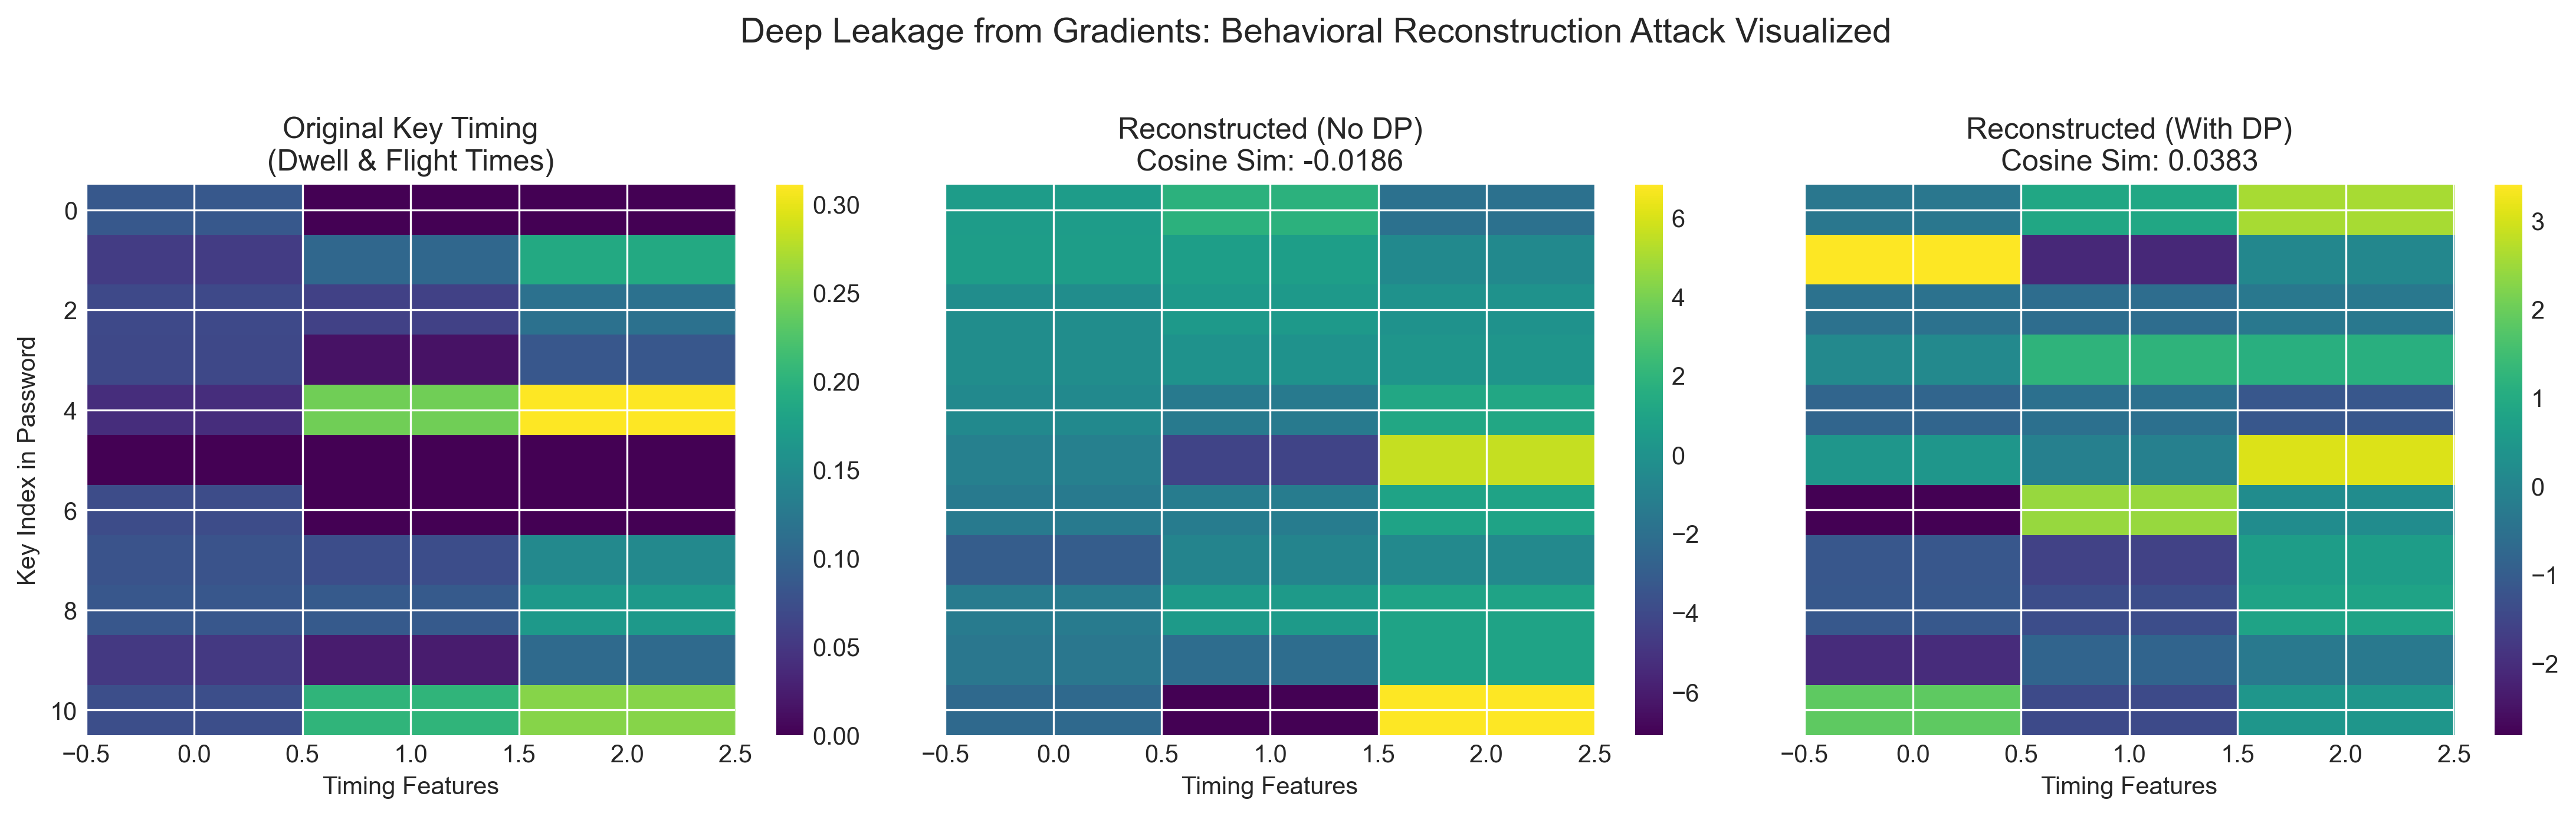

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import Image, display

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    return cwd

PROJECT_ROOT = resolve_project_root()
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

metrics_path = REPORTS_DIR / 'leakage_metrics.json'
if not metrics_path.exists():
    print('Running leakage attack...')
    sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
    import run_leakage_attack
    run_leakage_attack.main()

metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
print('Standard model reconstruction similarity (no DP):', metrics['standard_model'])
print('DP model reconstruction similarity (secured):', metrics['dp_model'])

img_path = FIGURES_DIR / 'gradient_reconstruction_leakage.png'
if img_path.exists():
    display(Image(filename=str(img_path)))